<a href="https://colab.research.google.com/github/leonovad/neuron-models/blob/main/lif_neuron2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leaky Integrate-and-Fire neuron: from membrane equation to F–I curve

A minimal spiking neuron model implemented from scratch in NumPy.
The membrane is treated as an RC circuit: a capacitor (lipid bilayer) in parallel
with a leak resistor (leak channels). When the membrane potential reaches a threshold,
a spike is registered and the potential is reset.

$$\tau \frac{dV}{dt} = -(V - V_{rest}) + R\,I$$

Parameters: $V_{rest} = -70$ mV, $V_{th} = -55$ mV, $V_{reset} = -75$ mV,
$R = 10$ MΩ, $\tau = 10$ ms. Integrated with the forward Euler method, $dt = 0.1$ ms.

*Part 1 of a two-part notebook. Part 2: Hodgkin–Huxley model.*

## 1. Response to a current step

A 100 ms current pulse is applied. Below rheobase the potential charges exponentially towards $V_\infty = V_{rest} + R\,I$ and stays subthreshold; above it the neuron fires repetitively.

Rheobase: $I_{rh} = \dfrac{V_{th} - V_{rest}}{R} = 1.5$ nA.

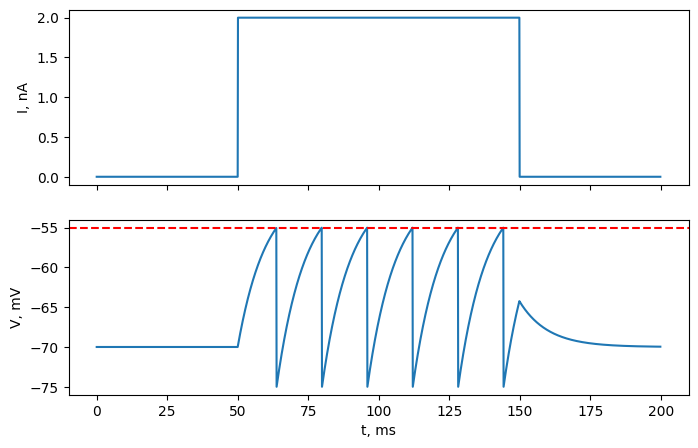

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate(I_amp, tau=10.0, t_ref=0.0):
    # Returns spike times (ms) for a 100 ms current step of amplitude I_amp (nA).
    V_rest, V_reset, V_th = -70.0, -75.0, -55.0   # mV
    R = 10.0                                      # MOhm
    dt, T = 0.1, 200.0                            # ms

    t = np.arange(0, T, dt)
    I = np.zeros_like(t)
    I[(t > 50) & (t < 150)] = I_amp

    V = np.full_like(t, V_rest)
    spikes = []
    last_spike = -1e9

    for i in range(1, len(t)):
        if t[i] - last_spike < t_ref:        # absolute refractory period
            V[i] = V_reset
            continue
        dV = (-(V[i-1] - V_rest) + R * I[i]) / tau
        V[i] = V[i-1] + dt * dV
        if V[i] >= V_th:
            spikes.append(t[i])
            V[i] = V_reset
            last_spike = t[i]
    return t, I, V, np.array(spikes)

t, I, V, sp = simulate(2.0)
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(t, I); ax[0].set_ylabel('I, nA')
ax[1].plot(t, V); ax[1].axhline(-55, ls='--', c='r')
ax[1].set_ylabel('V, mV'); ax[1].set_xlabel('t, ms')
plt.show()

## 2. F–I curve

Firing rate as a function of injected current. The simulation is wrapped in a function and evaluated for currents 0–6 nA.

The analytical inter-spike interval follows from solving the charging equation for $V(T) = V_{th}$:

$$T = \tau \ln \frac{V_\infty - V_{reset}}{V_\infty - V_{th}}$$

Near rheobase the denominator → 0, so $T \to \infty$ and the rate rises steeply from zero. For large currents $\ln x \approx x - 1$, and the curve approaches a straight line. The basic LIF has no upper bound on firing rate.

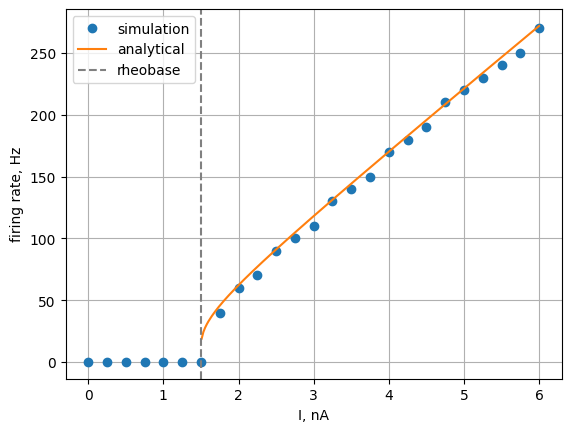

In [ ]:
# sweep current from 0 to 6 nA in 0.25 nA steps
currents = np.arange(0, 6.01, 0.25)
rates = []
for I_amp in currents:
    _, _, _, sp = simulate(I_amp)
    rates.append(len(sp) / 0.1)      # 100 ms window -> spikes per second (Hz)

# analytical curve (no refractory period)
I_an = np.linspace(1.51, 6, 200)
V_inf = -70 + 10 * I_an
T_an = 10 * np.log((V_inf + 75) / (V_inf + 55))   # ms
f_an = 1000 / T_an                                # Hz

plt.plot(currents, rates, 'o', label='simulation')
plt.plot(I_an, f_an, '-', label='analytical')
plt.axvline(1.5, ls='--', c='gray', label='rheobase')
plt.xlabel('I, nA'); plt.ylabel('firing rate, Hz'); plt.legend(); plt.grid(True)
plt.show()

## 3. Absolute refractory period

After each spike the potential is clamped at $V_{reset}$ for $t_{ref} = 2$ ms. The inter-spike interval becomes $T_{total} = t_{ref} + T$, which bounds the firing rate at $1000 / t_{ref} = 500$ Hz. The simulated curve now falls below the analytical no-refractory curve and flattens at high currents.

Note on resolution: spike counts over a 100 ms window are integers, so rates are quantised in 10 Hz steps — visible as plateaus. A longer window removes this.

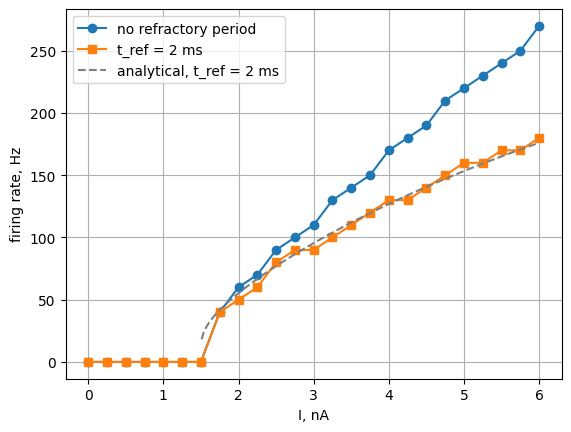

In [ ]:
rates_ref = []
for I_amp in currents:
    _, _, _, sp = simulate(I_amp, t_ref=2.0)
    rates_ref.append(len(sp) / 0.1)

f_an_ref = 1000 / (2.0 + T_an)     # analytical with refractory period

plt.plot(currents, rates, 'o-', label='no refractory period')
plt.plot(currents, rates_ref, 's-', label='t_ref = 2 ms')
plt.plot(I_an, f_an_ref, '--', c='gray', label='analytical, t_ref = 2 ms')
plt.xlabel('I, nA'); plt.ylabel('firing rate, Hz'); plt.legend(); plt.grid(True)
plt.show()

## Summary

- The LIF neuron reproduces two basic properties of real neurons: a current threshold (rheobase) and a monotonic F–I relation.
- Analytical and simulated F–I curves agree, validating the Euler implementation.
- Refractoriness caps the firing rate, as in real neurons.
- What LIF does not capture: the shape of the action potential and its ionic mechanism — addressed in Part 2 with the Hodgkin–Huxley model.